# Scaling 

Notebook to cover how the waves were scaled and then combined to generate synthetic records.

## Preamble

In [27]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [28]:
# setting up file path for imports
import sys
import os
from pathlib import Path

cwd = Path(os.getcwd())
print(cwd)
PROJECT_ROOT = cwd.resolve().parents[1]
sys.path.insert(0, str(PROJECT_ROOT))

# installing relevant libraries
import chaosmagpy as cp
import numpy as np
import matplotlib.pyplot as plt
import h5py
from pydmd import DMD, BOPDMD
from pydmd.preprocessing import hankel_preprocessing
import pickle

# Project paths / utilities
from src.msc_thesis.paths import *
from src.msc_thesis.synSetup import *
from src.msc_thesis.synUtils import *
from src.msc_thesis.synDMD import *

/home/elliott/projects/msc_thesis_project/Last_stretch/Data_prep


## loading in data, defining the power spectrum parameters

In [29]:
# spectrum paramaters

nmax = 15
print(dt_sample)



0.5


In [30]:
# CHAOS gauss coeffs
gnm_chaos = CHAOS_Full_SV_Record_Obtain()

# compute lowes psd
chaos_power, chaos_f = Lowes_Degree_PSD_All_Degrees(gnm_chaos, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax)

# first getting rid of all frequencies > 0.5
relevant_mask = (chaos_f < 0.5)
chaos_power = chaos_power[:, relevant_mask]

# all mode numbers in data set
mode_numbers = np.arange(1, 63, 1)
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

mode_spectra = []
mode_periods = []

amplitude_scalings = {}

total_power_chaos = np.sum(chaos_power)
total_power_modes = {}

# Synthetic gauss coeffs
for mode_number in mode_numbers:
    _, gnm_syn, mode_info = Synthetic_Full_SV_Record_Obtain([mode_number], times_used_relative, scale_flag=False)

    # compute lowes psd
    syn_power, syn_f = Lowes_Degree_PSD_All_Degrees(gnm_syn, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax)

    if np.allclose(syn_f, chaos_f) == False:
        print("frequency mismatch")
        continue

    syn_power = syn_power[:, relevant_mask]

    pointwise_power_factors = chaos_power/syn_power
    contact_power_factor = np.min(pointwise_power_factors)
    contact_amplitude_factor = np.sqrt(contact_power_factor)

    amplitude_scalings[mode_number] = contact_amplitude_factor

    mode_spectra.append(contact_power_factor * syn_power)

    total_power_mode = np.sum(contact_power_factor * syn_power)
    total_power_modes[mode_number] = total_power_mode

    period = (2*np.pi)/(mode_info[mode_number]["true_eigenvalue"].imag)
    mode_periods.append(period)



Full CHAOS-8.6 timespan is: [1997.1 2026.6]


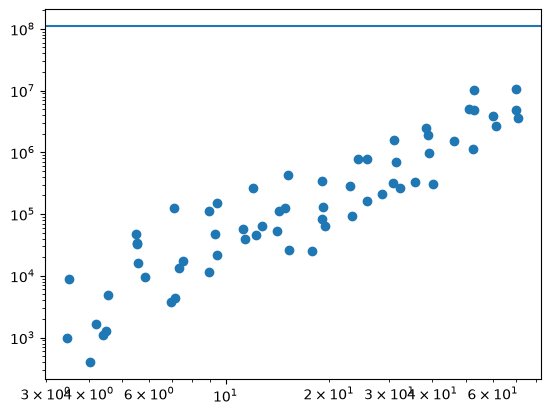

In [31]:
plt.loglog(mode_periods, total_power_modes.values(), 'o', label="modes")
plt.axhline(total_power_chaos)

In [32]:
felix_dir = Path(FELIX_DIR)

scalings_path = felix_dir / "amplitude_scalings.pkl"

with open(scalings_path, "wb") as file:
    pickle.dump(amplitude_scalings, file)

print(f"Saved amplitude scalings to: {scalings_path}")

Saved amplitude scalings to: /home/elliott/projects/msc_thesis_project/data/modes_surface/amplitude_scalings.pkl


## Combining waves into sets for record generation

In [33]:
# applying just to ideal synthetic record - equivalent to others
import numpy as np


def Fit_Wave_PSDs(
    wave_power,          # (n_modes, n_degrees, n_freqs)
    wave_periods,        # (n_modes,)
    target_power,        # (n_degrees, n_freqs)
    separation=0.25,
    max_factor=2.0,
    max_waves=None,
):
    wave_power = np.asarray(wave_power)
    wave_periods = np.asarray(wave_periods)
    target_power = np.asarray(target_power)

    Nmodes, Ndegrees, Nfrequencies = wave_power.shape

    if target_power.shape != (Ndegrees, Nfrequencies):
        raise ValueError(
            f"target_power has shape {target_power.shape}, "
            f"expected {(Ndegrees, Nfrequencies)}"
        )

    if len(wave_periods) != Nmodes:
        raise ValueError(
            f"Received {Nmodes} modes but "
            f"{len(wave_periods)} periods"
        )

    eps = 1e-12 * np.max(target_power)

    selected = []
    remaining = list(range(Nmodes))

    fitted_power = np.zeros_like(target_power, dtype=float)
    best_error = np.mean(
        np.log(
            (fitted_power + eps)
            / (target_power + eps)
        )**2
    )

    def periods_separated(candidate):
        Tc = wave_periods[candidate]

        return all(
            abs(Tc - wave_periods[j])
            / max(Tc, wave_periods[j]) > separation
            for j in selected
        )

    while remaining:
        if max_waves is not None and len(selected) >= max_waves:
            break

        best_candidate = None
        best_candidate_power = None
        best_candidate_error = best_error

        for candidate in remaining:
            if not periods_separated(candidate):
                continue

            trial_power = (
                fitted_power + wave_power[candidate]
            )

            # Reject combinations exceeding twice CHAOS power
            if np.any(
                trial_power > max_factor * target_power
            ):
                continue

            log_error = np.log(
                (trial_power + eps)
                / (target_power + eps)
            )

            trial_error = np.mean(log_error**2)

            if trial_error < best_candidate_error:
                best_candidate = candidate
                best_candidate_power = trial_power
                best_candidate_error = trial_error

        # No remaining mode improves the fit while satisfying
        # both constraints
        if best_candidate is None:
            break

        selected.append(best_candidate)
        remaining.remove(best_candidate)

        fitted_power = best_candidate_power
        best_error = best_candidate_error

    selected = np.asarray(selected, dtype=int)

    return {
        "selected_indices": selected,
        "selected_periods": wave_periods[selected],
        "fitted_power": fitted_power,
        "log_misfit": best_error,
    }

In [34]:

result = Fit_Wave_PSDs(
    wave_power=mode_spectra,
    wave_periods=mode_periods,
    target_power=chaos_power,
    separation=0.25,
    max_factor=2.0,
)


In [35]:
selected_modes = np.asarray(mode_numbers)[
    result["selected_indices"]
]

print("Selected modes:", selected_modes)



Selected modes: ['62' '6' '13' '48' '1' '45' '29']


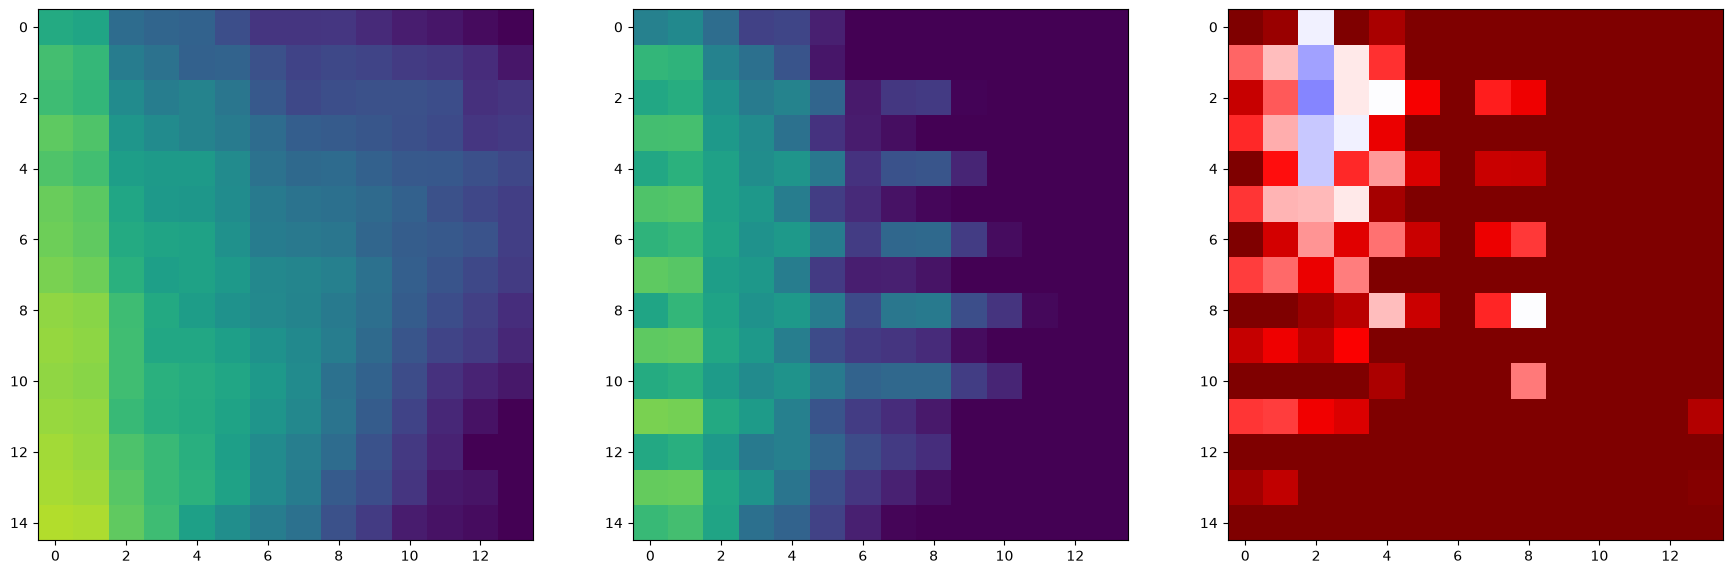

In [36]:

fig, axes = plt.subplots(figsize=(3*text_width, text_width), ncols=3)

axes[0].imshow(np.log10(chaos_power), vmin=0, vmax=8)
axes[1].imshow(np.log10(result["fitted_power"]), vmin=0, vmax=8)
axes[2].imshow((np.log10(chaos_power) - np.log10(result["fitted_power"])), vmin=-np.log10(10), vmax=np.log10(10), cmap='seismic')


In [37]:
# LOADING IN DATA

# defining modes used
mode_numbers = ['62', '6', '13', '48', '45', '1', '32']
mode_numbers = [str(mode_number) for mode_number in mode_numbers]

# defining spherical harmonic degree cutoff
nmax = 15

# CHAOS gauss coeffs
gnm_chaos = CHAOS_Full_SV_Record_Obtain()

# Synthetic gauss coeffs
_, gnm_syn, syn_suite_info = Synthetic_Full_SV_Record_Obtain(mode_numbers, times_used_relative)


print(np.shape(gnm_chaos))

gnm_syn_non_wave = Non_Wave_Spectral_Infill(gnm_chaos, gnm_syn, dt_sample=dt_sample, seed=3000)


Full CHAOS-8.6 timespan is: [1997.1 2026.6]
(53, 255)


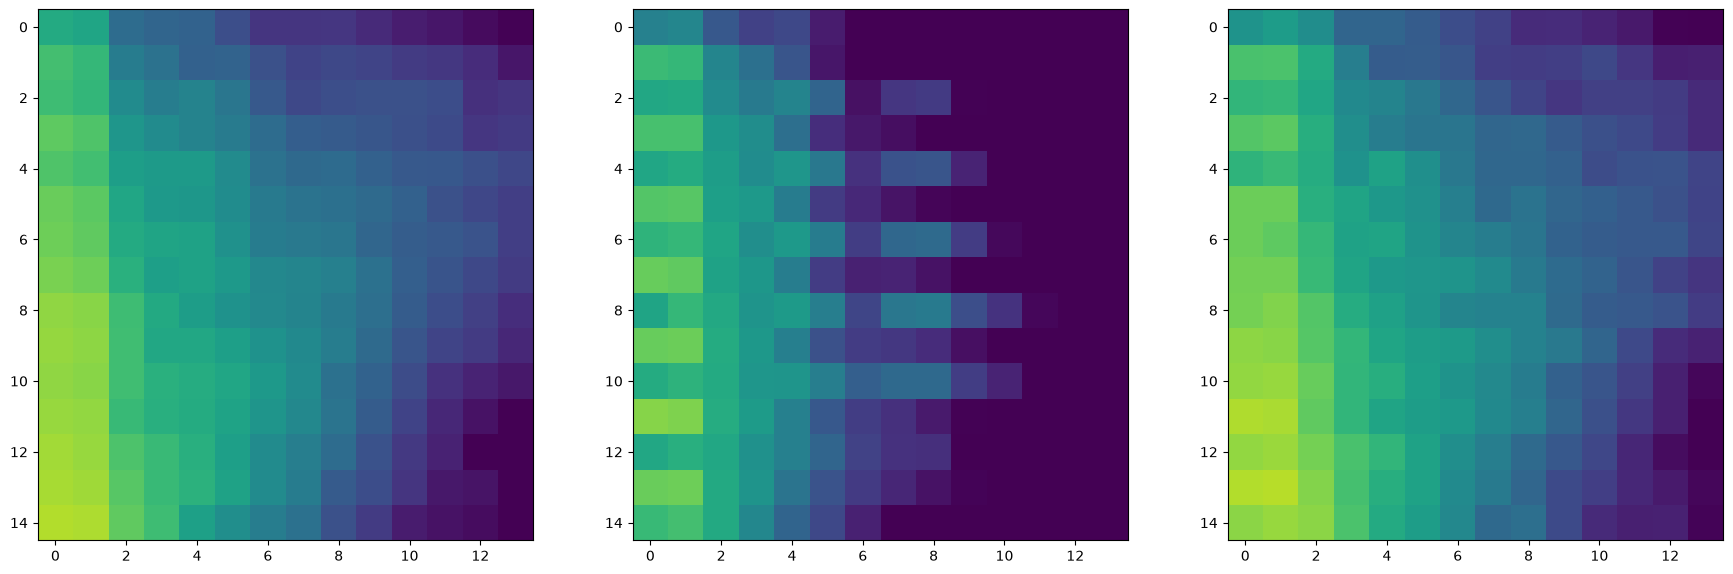

In [38]:
# first getting rid of all frequencies > 0.5
relevant_mask = (chaos_f < 0.5)
fig, axes = plt.subplots(figsize=(3*text_width, text_width), ncols=3)

axes[0].imshow(np.log10(Lowes_Degree_PSD_All_Degrees(gnm_chaos, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax)[0][:, relevant_mask]), vmin=0, vmax=8)
axes[1].imshow(np.log10(Lowes_Degree_PSD_All_Degrees(gnm_syn, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax)[0][:, relevant_mask]), vmin=0, vmax=8)
axes[2].imshow((np.log10(Lowes_Degree_PSD_All_Degrees(gnm_syn_non_wave+gnm_syn, a=r_earth, r=r_cmb, f_sample=f_sample, nmax=nmax)[0][:, relevant_mask])), vmin=0, vmax=8)

In [39]:
Cube_Movie((A_15_r @ gnm_syn_non_wave.T), name='nonlinear_background_approx_fixed')

'/home/elliott/projects/msc_thesis_project/figures/nonlinear_background_approx_fixed.mp4'